<a href="https://colab.research.google.com/github/papertuc2000/CL-Drive/blob/BUS/BreastCancerSegmentation_model.fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import cv2
import re
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from glob import glob

import tensorflow as tf
import keras.backend as K
from keras import Model
from keras.layers import *
from keras.losses import Loss
from keras.utils import Sequence, to_categorical, load_img, img_to_array
from keras.preprocessing.image import smart_resize

from sklearn.model_selection import StratifiedKFold, KFold

In [20]:
class Metrics:
    def _confusion_matrix_elements(self, y_true, y_pred, class_id, is_binary, across_batch=False):
        # Apply thresholding for binary classification (sigmoid output)
        if is_binary:
            y_pred=tf.where(y_pred >= 0.5, 1.0, 0.0)
            y_pred_binary=tf.cast(y_pred == class_id, tf.float32)
            y_true_binary=tf.cast(y_true == class_id, tf.float32)
        else:
            # Multi-class case (softmax output)
            y_true_binary=tf.cast(tf.argmax(y_true, axis=-1) == class_id, tf.float32)
            y_pred_binary=tf.cast(tf.argmax(y_pred, axis=-1) == class_id, tf.float32)

        # Use tf.cond for graph-compatible conditional logic
        condition = tf.equal(tf.rank(y_true_binary), 2)

        def true_fn(): # Case where rank is 2 (height, width)
            TP = tf.reduce_sum(tf.cast((y_true_binary == 1) & (y_pred_binary == 1), tf.float32))
            FP = tf.reduce_sum(tf.cast((y_true_binary == 0) & (y_pred_binary == 1), tf.float32))
            TN = tf.reduce_sum(tf.cast((y_true_binary == 0) & (y_pred_binary == 0), tf.float32))
            FN = tf.reduce_sum(tf.cast((y_true_binary == 1) & (y_pred_binary == 0), tf.float32))
            return TP, FP, TN, FN

        def false_fn(): # Case where rank is > 2 (e.g., batch, height, width)
            TP = tf.reduce_sum(tf.cast((y_true_binary == 1) & (y_pred_binary == 1), tf.float32), axis=[1, 2])
            FP = tf.reduce_sum(tf.cast((y_true_binary == 0) & (y_pred_binary == 1), tf.float32), axis=[1, 2])
            TN = tf.reduce_sum(tf.cast((y_true_binary == 0) & (y_pred_binary == 0), tf.float32), axis=[1, 2])
            FN = tf.reduce_sum(tf.cast((y_true_binary == 1) & (y_pred_binary == 0), tf.float32), axis=[1, 2])

            if not across_batch:
                TP = tf.reduce_mean(TP)
                FP = tf.reduce_mean(FP)
                TN = tf.reduce_mean(TN)
                FN = tf.reduce_mean(FN)
            return TP, FP, TN, FN

        TP, FP, TN, FN = tf.cond(condition, true_fn, false_fn)

        return TP, FP, TN, FN

    def _get_num_classes(self, y_true, y_pred):
        """Helper function to determine if the problem is binary or multi-class."""
        if np.shape(y_pred)[-1] == 1:  # Binary classification case (sigmoid output)
            return 2, True
        elif np.shape(y_pred)[-1] == 2:  # Binary classification case (softmax with two outputs)
            return 2, False
        else:  # Multi-class case (softmax output)
            return np.shape(y_pred)[-1], False

    def _compute_metric(self, y_true, y_pred, metric_fn, across_classes=True):
        """Generic method to compute metrics across classes."""
        num_classes, is_binary=self._get_num_classes(y_true, y_pred)
        metric_sum=0.0

        if across_classes:
            for class_id in range(num_classes):
                TP, FP, TN, FN=self._confusion_matrix_elements(y_true, y_pred, class_id, is_binary)
                metric_sum += metric_fn(TP, FP, TN, FN)

            return metric_sum / tf.cast(num_classes, tf.float32)
        else:
            metric=[]
            for class_id in range(num_classes):
                TP, FP, TN, FN=self._confusion_matrix_elements(y_true, y_pred, class_id, is_binary)
                metric.append(metric_fn(TP, FP, TN, FN))

            return metric

    def _compute_class_weights(self, y_true):
        total_pixels=tf.reduce_prod(tf.shape(y_true)[:-1])
        class_pixel_counts=tf.reduce_sum(y_true, axis=[0, 1, 2])
        class_ratios=class_pixel_counts / tf.cast(total_pixels, tf.float32)
        class_weights=1.0 - class_ratios

        return class_weights

    # Metrics
    def precision(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TP / (TP + FP + K.epsilon()))

    def recall(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TP / (TP + FN + K.epsilon()))

    def f1_score(self, y_true, y_pred):
        precision_value=self.precision(y_true, y_pred)
        recall_value=self.recall(y_true, y_pred)
        return 2 * (precision_value * recall_value) / (precision_value + recall_value + K.epsilon())

    def accuracy(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: (TP + TN) / (TP + FP + TN + FN + K.epsilon()))

    def dice(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: (2 * TP) / (2 * TP + FP + FN + K.epsilon()))

    def iou(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TP / (TP + FP + FN + K.epsilon()))

    def specificity(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TN / (TN + FP + K.epsilon()))

    def sensitivity(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TP / (TP + FN + K.epsilon()))

    def fp_rate(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: FP / (FP + TN + K.epsilon()))

    def fn_rate(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: FN / (FN + TP + K.epsilon()))

    def negative_predictive(self, y_true, y_pred):
        return self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: TN / (TN + FN + K.epsilon()))

    # Loss functions
    def focal_loss(self, y_true, y_pred, gamma=2.0):
        num_classes, is_binary=self._get_num_classes(y_true, y_pred)

        if is_binary:
            # Binary classification case (sigmoid output)
            ce_loss=tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=y_pred)
            probs=tf.nn.sigmoid(y_pred)
            loss=tf.reduce_mean(((1 - probs) ** gamma) * ce_loss)
        else:
            # Multi-class classification case (softmax output)
            loss=0.0

            for class_id in range(num_classes):
                y_true_binary=tf.cast(tf.argmax(y_true, axis=-1) == class_id, tf.float32)
                y_pred_logits=y_pred[..., class_id]

                ce_loss=tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true_binary, logits=y_pred_logits)
                probs=tf.nn.sigmoid(y_pred_logits)

                class_focal_loss=tf.reduce_mean(((1 - probs) ** gamma) * ce_loss)
                loss += class_focal_loss

            loss /= tf.cast(num_classes, tf.float32)

        return loss

    def tversky_loss(self, y_true, y_pred, alpha=0.5, beta=0.5):
        num_classes, is_binary=self._get_num_classes(y_true, y_pred)

        if is_binary:
            TP, FP, _, FN=self._confusion_matrix_elements(y_true, y_pred, class_id=1, is_binary=is_binary)
        else:
            TP_total=tf.zeros(())
            FP_total=tf.zeros(())
            FN_total=tf.zeros(())

            for class_id in range(num_classes):
                TP, FP, _, FN=self._confusion_matrix_elements(y_true, y_pred, class_id, is_binary=is_binary)
                TP_total += TP
                FP_total += FP
                FN_total += FN

            # Compute average confusion matrix elements for multi-class
            TP=TP_total / tf.cast(num_classes, tf.float32)
            FP=FP_total / tf.cast(num_classes, tf.float32)
            FN=FN_total / tf.cast(num_classes, tf.float32)

        # Compute Tversky index and loss
        tversky_index=TP / (TP + alpha * FP + beta * FN + K.epsilon())

        return 1 - tversky_index

    def dice_loss(self, y_true, y_pred):
        return 1 - self.dice(y_true, y_pred)

    def iou_loss(self, y_true, y_pred):
        return 1 - self.iou(y_true, y_pred)

    def precision_loss(self, y_true, y_pred):
        return 1 - self.precision(y_true, y_pred)

    def recall_loss(self, y_true, y_pred):
        return 1 - self.recall(y_true, y_pred)

    def f1_score_loss(self, y_true, y_pred):
        return 1 - self.f1_score(y_true, y_pred)

    # Custom metric and loss function
    def class_balanced_index(self, y_true, y_pred):
        loss_index=self._compute_metric(y_true, y_pred, lambda TP, FP, TN, FN: (2 * TP) / (2 * TP + FP + FN + K.epsilon()), across_classes=False)
        class_weights=self._compute_class_weights(y_true)
        index=tf.reduce_sum(class_weights * loss_index)
        return index

    def class_balanced_loss(self, y_true, y_pred):
        return 1 - self.class_balanced_index(y_true, y_pred)


# Instantiate the Metrics class for easy access to the methods
metrics_instance=Metrics()


# Individual function definitions for easy use in Keras models
def precision(y_true, y_pred):
    return metrics_instance.precision(y_true, y_pred)


def recall(y_true, y_pred):
    return metrics_instance.recall(y_true, y_pred)


def f1_score(y_true, y_pred):
    return metrics_instance.f1_score(y_true, y_pred)


def accuracy(y_true, y_pred):
    return metrics_instance.accuracy(y_true, y_pred)


def dice(y_true, y_pred):
    return metrics_instance.dice(y_true, y_pred)


def iou(y_true, y_pred):
    return metrics_instance.iou(y_true, y_pred)


def specificity(y_true, y_pred):
    return metrics_instance.specificity(y_true, y_pred)


def sensitivity(y_true, y_pred):
    return metrics_instance.sensitivity(y_true, y_pred)


def dice_loss(y_true, y_pred):
    return metrics_instance.dice_loss(y_true, y_pred)


def iou_loss(y_true, y_pred):
    return metrics_instance.iou_loss(y_true, y_pred)


def precision_loss(y_true, y_pred):
    return metrics_instance.precision_loss(y_true, y_pred)


def recall_loss(y_true, y_pred):
    return metrics_instance.recall_loss(y_true, y_pred)


def f1_score_loss(y_true, y_pred):
    return metrics_instance.f1_score_loss(y_true, y_pred)


def focal_loss(y_true, y_pred):
    return metrics_instance.focal_loss(y_true, y_pred)


def tversky_loss(y_true, y_pred):
    return metrics_instance.tversky_loss(y_true, y_pred)


def class_balanced_index(y_true, y_pred):
    return metrics_instance.class_balanced_index(y_true, y_pred)


def class_balanced_loss(y_true, y_pred):
    return metrics_instance.class_balanced_loss(y_true, y_pred)


def fp_rate(y_true, y_pred):
    return metrics_instance.fp_rate(y_true, y_pred)


def fn_rate(y_true, y_pred):
    return metrics_instance.fn_rate(y_true, y_pred)


def negative_predictive(y_true, y_pred):
    return metrics_instance.negative_predictive(y_true, y_pred)

In [5]:
def DownSamplingBlock(input_layer,
                      filters,
                      kernel_size=3,
                      padding='same',
                      strides=1,
                      pool_size=2,
                      negative_slope=.25,
                      use_drop=True,
                      drop_rate=.1,
                      bottleneck=False):
    d=Conv2D(filters=filters, kernel_size=kernel_size, padding=padding, strides=strides,
               kernel_initializer='he_normal', bias_initializer='he_normal')(input_layer)
    d=BatchNormalization()(d)
    if negative_slope:
        d=LeakyReLU(alpha=negative_slope)(d)
    else:
        d=Activation('relu')(d)
    d=Conv2D(filters=filters, kernel_size=kernel_size, padding=padding, strides=1,
               kernel_initializer='he_normal', bias_initializer='he_normal')(d)
    d=BatchNormalization()(d)
    if negative_slope:
        d=LeakyReLU(alpha=negative_slope)(d)
    else:
        d=Activation('relu')(d)

    if bottleneck:
        return d

    p=MaxPooling2D(pool_size=pool_size)(d)
    if use_drop and drop_rate:
        p=Dropout(rate=drop_rate)(p)

    return d, p

In [6]:
def UpSamplingBlock(input_layer,
                    up_layer,
                    filters,
                    kernel_size=3,
                    padding='same',
                    strides=2,
                    use_convtranspose=True,
                    negative_slope=.25,
                    use_drop=True,
                    drop_rate=.1):
    if use_convtranspose:
        u=Conv2DTranspose(filters=filters, kernel_size=kernel_size, padding=padding, strides=strides,
                            kernel_initializer='he_normal', bias_initializer='he_normal')(input_layer)
        u=BatchNormalization()(u)
        if negative_slope:
            u=LeakyReLU(alpha=negative_slope)(u)
        else:
            u=Activation('relu')(u)
        u=Concatenate()([u, up_layer])
        if use_drop and drop_rate:
            u=Dropout(rate=drop_rate)(u)
        u=Conv2D(filters=filters, kernel_size=3, padding=padding, kernel_initializer='he_normal', bias_initializer='he_normal')(u)
        u=BatchNormalization()(u)
        if negative_slope:
            u=LeakyReLU(alpha=negative_slope)(u)
        else:
            u=Activation('relu')(u)
        u=Conv2D(filters=filters, kernel_size=3, padding=padding, kernel_initializer='he_normal', bias_initializer='he_normal')(u)
        u=BatchNormalization()(u)
        if negative_slope:
            u=LeakyReLU(alpha=negative_slope)(u)
        else:
            u=Activation('relu')(u)
    else:
        u=UpSampling2D(size=strides)(input_layer)
        if use_drop and drop_rate:
            u=Dropout(rate=drop_rate)(u)

    return u

In [7]:
def FinalBlock(input_layer, num_classes, kernel_size=1, padding='same'):
    output=Conv2D(filters=num_classes, kernel_size=kernel_size, padding=padding,
                    kernel_initializer='he_normal', bias_initializer='he_normal')(input_layer)
    output=BatchNormalization()(output)
    if num_classes > 1:
        output=Activation('softmax')(output)
    else:
        output=Activation('sigmoid')(output)

    return output

In [8]:
def simple_unet(input_shape=(240, 240, 3), num_classes=2, filters=16, depth=3, use_convtranspose=True, negative_slope=.25, use_drop=True, drop_rate=.05):
    # Define the input layer of the model.
    inputs=Input(shape=input_shape)

    ## Encoder path:
    # To store connections for the skip connections in the decoder.
    skips=[]
    x=inputs

    # Encoder loop
    for i in range(depth):
        x, pool=DownSamplingBlock(x, filters * (2 ** i), use_drop=use_drop, drop_rate=drop_rate, negative_slope=negative_slope)
        skips.append(x)  # store the conv output for skip connections
        x=pool

    ## Bottleneck:
    # The deepest layer of the network.
    x=DownSamplingBlock(x, filters * (2 ** depth), negative_slope=negative_slope, bottleneck=True)

    ## Decoder path:
    # Reverse the skip connections for use in upsampling blocks
    for i in reversed(range(depth)):
        x=UpSamplingBlock(x, skips[i], filters * (2 ** i), use_convtranspose=use_convtranspose, negative_slope=negative_slope, use_drop=use_drop, drop_rate=drop_rate)

    # Output layer:
    # Final block to refine the output features and produce the final segmentation map or classification output.
    output=FinalBlock(x, num_classes)

    # Create and return the model with specified inputs and outputs.
    return Model(inputs=inputs, outputs=output, name='unet')

In [9]:
def get_image_and_mask_paths(root_path):
    image_paths = []
    mask_paths = []

    file_extension_image = '.png'
    file_extension_mask = '.png'

    for subfolder in os.listdir(root_path):
        subfolder_path = os.path.join(root_path, subfolder)

        images = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path)
                  if f.endswith(file_extension_image) and all(m not in os.path.join(subfolder_path, f).lower() for m in ('mask', 'masks'))]
        masks = [os.path.join(subfolder_path, f) for f in os.listdir(subfolder_path)
                 if f.endswith(file_extension_mask) and any(m in os.path.join(subfolder_path, f).lower() for m in ('mask', 'masks'))]
        if images:
            images.sort()
        if masks:
            masks.sort()

        if 'Data01' in root_path:
            for image in images:
                base_name = os.path.basename(image).replace('.png', '')
                masks_for_image = [m for m in masks if base_name in m]
                if masks_for_image:
                    image_paths.append(image)
                    mask_paths.append(masks_for_image)
        elif os.path.basename(root_path) in ['Data02', 'Data03']:
            if images:
                image_paths.extend(np.sort(images))
            if masks:
                mask_paths.extend(np.sort(masks))

    return image_paths, mask_paths

In [10]:
def plot_dataset_samples(generator, num_rows, class_color_label=None, reverse_pixel=True):
    if class_color_label is None:
        class_color_label={0: (0, 0, 0), 1: (255, 255, 255)}  # default is black and white

    image_batch, mask_batch=generator[0]
    num_rows=min(num_rows, len(image_batch))

    plt.figure(figsize=(15, 5 * num_rows))

    for i, batch in enumerate(zip(image_batch[:num_rows], mask_batch[:num_rows])):
        image, mask=batch
        if reverse_pixel:
            image=1 - image

        # If the mask has multiple channels, collapse it to a single channel using argmax
        if np.shape(mask)[-1] > 1:
            mask=np.argmax(mask, axis=-1)

        # Apply the color mask to the true mask
        colored_mask=apply_color_mask(mask, class_color_label)

        # Plot the image
        plt.subplot(num_rows, 3, 3 * i + 1)
        plt.imshow(image, cmap='magma')
        plt.title(f"Image {i+1}")
        plt.axis('off')

        # Plot the mask with color labels
        plt.subplot(num_rows, 3, 3 * i + 2)
        plt.imshow(colored_mask)
        plt.title(f"Mask {i+1}")
        plt.axis('off')

        # Overlay the mask on the image
        plt.subplot(num_rows, 3, 3 * i + 3)
        plt.imshow(image, cmap='magma')
        plt.imshow(colored_mask, alpha=0.4)  # Overlay mask with transparency
        plt.title(f"Overlay {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [11]:
def visualize_test_samples(data_generator, model, num_samples=5, class_color_label=None, just_save=False, save_path=None, index=0, data_mode='train', reverse_pixel=True):
    if class_color_label is None:
        class_color_label={0: (0, 0, 0), 1: (255, 255, 255)}

    # Get the images and masks from the data generator
    images, masks=data_generator[0]

    # Create directories to save images if a save_path is provided
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        image_save_path=os.path.join(save_path, f'visualize_{data_mode}_samples_{index}')
        os.makedirs(image_save_path, exist_ok=True)

    if not just_save:
        num_samples=np.min([num_samples, np.shape(images)[0]])
        fig, axes=plt.subplots(num_samples, 3, figsize=(16, num_samples * 5))

    indices=np.random.choice(np.arange(len(images)), size=num_samples, replace=False)

    for i in range(num_samples):
        if reverse_pixel:
            image=1 - images[indices[i]]
        else:
            image=images[indices[i]]
        mask=masks[indices[i]]

        # If the mask has multiple channels, collapse it to a single channel
        if np.shape(mask)[-1] > 1:
            mask=np.argmax(mask, axis=-1)

        # Predict the mask using the model
        predicted_mask=model.predict(np.expand_dims(image, axis=0), verbose=0)[0]

        # If the predicted mask has multiple channels, collapse it to a single channel
        if np.shape(predicted_mask)[-1] > 1:
            predicted_mask=np.argmax(predicted_mask, axis=-1)
        else:
            predicted_mask=np.where(predicted_mask >= 0.5, 1, 0)

        # Apply class color labels to the true mask and predicted mask
        colored_true_mask=apply_color_mask(mask, class_color_label)
        colored_pred_mask=apply_color_mask(predicted_mask, class_color_label)

        if not just_save:
            # Display the input image, true mask, and predicted mask
            axes[i, 0].imshow(image, cmap='magma')
            axes[i, 0].set_title("Input Image")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(colored_true_mask)
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis('off')

            axes[i, 2].imshow(colored_pred_mask)
            axes[i, 2].set_title("Predicted Mask")
            axes[i, 2].axis('off')

        # Save individual images if a save_path is provided
        if save_path is not None:
            plt.imsave(os.path.join(image_save_path, f"image_{i}_input.png"), np.squeeze(image), cmap='magma')
            plt.imsave(os.path.join(image_save_path, f"image_{i}_true_mask.png"), colored_true_mask)
            plt.imsave(os.path.join(image_save_path, f"image_{i}_pred_mask.png"), colored_pred_mask)

    if not just_save:
        plt.tight_layout()
        # Save the entire figure as a PDF if save_path is provided
        if save_path is not None:
            fig_save_path=os.path.join(image_save_path, f"{data_mode}_samples_visualization.pdf")
            fig.savefig(fig_save_path, format='pdf')

        plt.show()

In [12]:
def apply_color_mask(mask, class_color_label):
    colored_mask=np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_label, color in class_color_label.items():
        colored_mask[mask == class_label]=color

    return colored_mask

In [13]:
class ImageMaskGenerator(Sequence):
    def __init__(self,
                 image_paths,
                 mask_paths,
                 batch_size,
                 size,
                 data_mode='train',
                 return_one_hot=True,
                 num_classes=2,
                 augmentation=True,
                 apply_bilateral_filter=False,
                 test_size=0.1,
                 val_size=0.1,
                 flip_prob=0.1,
                 flip_left_right_prob=0.1,
                 rotation_prob=0.1,
                 shift_percentage=0.1,
                 shift_prob=0.1,
                 shift_with_zero_padding=True,
                 reverse_pixel=True,
                 save_path=None,
                 use_previous_attempt=False,
                 using_kfold=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.size = size
        self.data_mode = data_mode
        if self.data_mode not in ['train', 'val', 'test']:
            raise ValueError("Invalid data_mode. Must be 'train', 'val', or 'test'.")
        self.return_one_hot = return_one_hot
        self.num_classes = num_classes
        self.augmentation = augmentation
        self.apply_bilateral_filter = apply_bilateral_filter
        self.test_size = test_size
        self.val_size = val_size
        if self.val_size <= 0.0:
            self.val_size = 0.0
        self.flip_prob = flip_prob
        self.flip_left_right_prob = flip_left_right_prob
        self.rotation_prob = rotation_prob
        self.shift_percentage = shift_percentage
        self.shift_prob = shift_prob
        self.shift_with_zero_padding = shift_with_zero_padding
        self.reverse_pixel = reverse_pixel
        self.save_path = save_path
        self.use_previous_attempt = use_previous_attempt
        self.using_kfold = using_kfold

        if not self.use_previous_attempt:
            self._split_data()
        self._load_splitted_data()
        self.indices = np.arange(len(self.image_paths))
        if self.batch_size > len(self.image_paths):
            print(f"[{self.data_mode.upper()}] Batch size ({self.batch_size}) is larger than the number of images ({len(self.image_paths)}). Batch size is set to {len(self.image_paths)}.")
            self.batch_size = len(self.image_paths)
        self.current_index = 0

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __iter__(self):
        self.current_index = 0
        return self

    def __next__(self):
        if self.current_index >= len(self):
            raise StopIteration
        batch = self.__getitem__(self.current_index)
        self.current_index += 1
        return batch

    def __getitem__(self, index):
        if self.data_mode == 'val' and self.val_size == 0.0:
            print("Validation data is empty due to: 'val_size' is set to 0.0!")
            images, masks = [], []
            return tf.cast(tf.stack(images), dtype=tf.float32), tf.cast(tf.stack(masks), dtype=tf.float32)
        start_index = index * self.batch_size
        end_index = min((index + 1) * self.batch_size, len(self.image_paths))

        batch_image_paths = self.image_paths[start_index:end_index]
        batch_mask_paths = self.mask_paths[start_index:end_index]

        images = [self._load_image(image_path) for image_path in batch_image_paths]
        masks = [self._load_and_merge_masks(mask_path) for mask_path in batch_mask_paths]

        if self.apply_bilateral_filter:
            images = [self._bilateral_filter(image) for image in images]

        if self.augmentation:
            images, masks = zip(*[self._apply_augmentation(image, mask) for image, mask in zip(images, masks)])

        if self.return_one_hot and self.num_classes > 1:
            if len(tf.shape(masks)) == 4:
                masks = tf.squeeze(masks, axis=-1)
            masks = to_categorical(masks, num_classes=self.num_classes)

        return tf.cast(tf.stack(images), dtype=tf.float32), tf.cast(tf.stack(masks), dtype=tf.float32)

    def _load_image(self, image_path):
        img = load_img(image_path, color_mode='grayscale')
        if self.reverse_pixel:
            img_array = (255.0 - img_to_array(img)) / 255.0
        else:
            img_array = img_to_array(img) / 255.0
        resized_img = smart_resize(img_array, (self.size, self.size))

        return resized_img

    def _load_and_merge_masks(self, mask_paths):
        merged_mask = np.zeros((self.size, self.size, 1))
        if isinstance(mask_paths, str):
            mask_paths = [mask_paths]
        for mask_path in mask_paths:
            mask = load_img(mask_path, color_mode='grayscale')
            mask_array = np.float32(np.ceil(img_to_array(mask) / 255.0))
            resized_mask = smart_resize(mask_array, (self.size, self.size))
            overlap_mask = (resized_mask != 0) & (merged_mask == 0)
            merged_mask = np.where(overlap_mask & (resized_mask == merged_mask), resized_mask, np.maximum(resized_mask, merged_mask))
            # merged_mask += resized_mask

        return merged_mask

    def _split_data(self):
        if self.test_size + self.val_size >= 0.5:
            raise ValueError("Test size and validation size combined must be less than 0.5.")

        assert len(self.image_paths) == len(self.mask_paths), "Image and mask paths must have the same length."

        all_indices = np.arange(len(self.image_paths))
        np.random.shuffle(all_indices)

        if self.using_kfold:
            if os.path.isfile(os.path.join(self.save_path, f'{self.data_mode}_indices.txt')):
                os.remove(os.path.join(self.save_path, f'{self.data_mode}_indices.txt'))
            with open(os.path.join(self.save_path, f'{self.data_mode}_indices.txt'), 'w') as f:
                f.write('\n'.join(map(str, all_indices)))
        else:
            train_indices, val_indices, test_indices = [], [], []
            test_indices = all_indices[:int(len(all_indices) * self.test_size)]
            if self.val_size:
                val_indices = all_indices[int(len(all_indices) * self.test_size):int(len(all_indices) * (self.test_size + self.val_size))]
            train_indices = all_indices[int(len(all_indices) * (self.test_size + self.val_size)):]

            if os.path.isfile(os.path.join(self.save_path, 'train_indices.txt')):
                os.remove(os.path.join(self.save_path, 'train_indices.txt'))
            if self.val_size:
                if os.path.isfile(os.path.join(self.save_path, 'val_indices.txt')):
                    os.remove(os.path.join(self.save_path, 'val_indices.txt'))
            if os.path.isfile(os.path.join(self.save_path, 'test_indices.txt')):
                os.remove(os.path.join(self.save_path, 'test_indices.txt'))

            with open(os.path.join(self.save_path, 'train_indices.txt'), 'w') as f:
                f.write('\n'.join(map(str, train_indices)))
            if self.val_size:
                with open(os.path.join(self.save_path, 'val_indices.txt'), 'w') as f:
                    f.write('\n'.join(map(str, val_indices)))
            with open(os.path.join(self.save_path, 'test_indices.txt'), 'w') as f:
                f.write('\n'.join(map(str, test_indices)))

            if self.data_mode == 'train':
                print(f"Number of training samples: {len(train_indices)}")
            if self.val_size:
                if self.data_mode == 'val':
                    print(f"Number of validation samples: {len(val_indices)}")
            if self.data_mode == 'test':
                print(f"Number of testing samples: {len(test_indices)}")

    def _load_splitted_data(self):
        if self.data_mode not in ['train', 'val', 'test']:
            raise ValueError("Invalid data_mode. Must be 'train', 'val', or 'test'.")

        try:
            with open(os.path.join(self.save_path, f'{self.data_mode}_indices.txt'), 'r') as f:
                indices = list(map(int, f.read().splitlines()))
        except FileNotFoundError:
            f = os.path.join(self.save_path, f'{self.data_mode}_indices.txt')
            raise FileNotFoundError(f"Index file for {self.data_mode} mode not found. Ensure {f} exists.")
        except ValueError:
            raise ValueError(f"Corrupt index file for {self.data_mode} mode. Ensure it contains valid integer indices.")

        # Check if indices are in bounds for the image and mask paths
        max_index = len(self.image_paths) - 1
        for i in indices:
            if i < 0 or i > max_index:
                f = os.path.join(self.save_path, f'{self.data_mode}_indices.txt')
                raise IndexError(f"Index {i} in {f} is out of bounds (0 to {max_index}).")

        # Load images and masks using valid indices
        self.image_paths = [self.image_paths[i] for i in indices]
        self.mask_paths = [self.mask_paths[i] for i in indices]

    def _bilateral_filter(self, image, d=9, sigmaColor=45, sigmaSpace=45):
        if np.max(image) == 1:
            image = np.uint8(image * 255)
        filtered_image = cv2.bilateralFilter(image, d=d, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)
        filtered_image = np.float32(filtered_image / 255)
        if len(np.shape(filtered_image)) == 2:
            filtered_image = tf.expand_dims(filtered_image, axis=-1)

        return filtered_image

    def _apply_augmentation(self, image, mask):
        if np.random.rand() < self.flip_prob:
            if np.random.rand() < self.flip_left_right_prob:
                image = tf.image.flip_left_right(image)
                mask = tf.image.flip_left_right(mask)

        if np.random.rand() < self.rotation_prob:
            k = tf.random.uniform([], minval=1, maxval=4, dtype=tf.int32)
            image = tf.image.rot90(image, k=k)
            mask = tf.image.rot90(mask, k=k)

        if np.random.rand() < self.shift_prob:
            image_height, image_width = image.shape[0], image.shape[1]
            shift_pixels_w = int(image_width * self.shift_percentage)
            shift_pixels_h = int(image_height * self.shift_percentage)

            direction = tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)

            if direction == 0:
                if self.shift_with_zero_padding:
                    image = tf.pad(image, [[0, 0], [shift_pixels_w, 0], [0, 0]], mode='CONSTANT', constant_values=0)[:, :-shift_pixels_w, :]
                    mask = tf.pad(mask, [[0, 0], [shift_pixels_w, 0], [0, 0]], mode='CONSTANT', constant_values=0)[:, :-shift_pixels_w, :]
                else:
                    image = tf.roll(image, shift=-shift_pixels_w, axis=1)
                    mask = tf.roll(mask, shift=-shift_pixels_w, axis=1)
            if direction == 1:
                if self.shift_with_zero_padding:
                    image = tf.pad(image, [[0, 0], [0, shift_pixels_w], [0, 0]], mode='CONSTANT', constant_values=0)[:, shift_pixels_w:, :]
                    mask = tf.pad(mask, [[0, 0], [0, shift_pixels_w], [0, 0]], mode='CONSTANT', constant_values=0)[:, shift_pixels_w:, :]
                else:
                    image = tf.roll(image, shift=shift_pixels_w, axis=1)
                    mask = tf.roll(mask, shift=shift_pixels_w, axis=1)
            if direction == 2:
                if self.shift_with_zero_padding:
                    image = tf.pad(image, [[shift_pixels_h, 0], [0, 0], [0, 0]], mode='CONSTANT', constant_values=0)[:-shift_pixels_h, :, :]
                    mask = tf.pad(mask, [[shift_pixels_h, 0], [0, 0], [0, 0]], mode='CONSTANT', constant_values=0)[:-shift_pixels_h, :, :]
                else:
                    image = tf.roll(image, shift=-shift_pixels_h, axis=0)
                    mask = tf.roll(mask, shift=-shift_pixels_h, axis=0)
            if direction == 3:
                if self.shift_with_zero_padding:
                    image = tf.pad(image, [[0, shift_pixels_h], [0, 0], [0, 0]], mode='CONSTANT', constant_values=0)[shift_pixels_h:, :, :]
                    mask = tf.pad(mask, [[0, shift_pixels_h], [0, 0], [0, 0]], mode='CONSTANT', constant_values=0)[shift_pixels_h:, :, :]
                else:
                    image = tf.roll(image, shift=shift_pixels_h, axis=0)
                    mask = tf.roll(mask, shift=shift_pixels_h, axis=0)

        return image, mask

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

In [14]:
def plot_data(file_data, over_epoch=False, compute_stats=False, num_batch=4, save_path=None):
    # plt.style.use('seaborn')
    sns.set_theme()
    if save_path is not None:
        os.makedirs(save_path, exist_ok=True)
        image_save_path=os.path.join(save_path, 'visualize_results')
        os.makedirs(image_save_path, exist_ok=True)
        epoch_map={True: 'Epoch', False: 'Batch'}
        stats_map={True: 'Stats', False: 'NonStats'}
        labels=[epoch_map[over_epoch], stats_map[compute_stats]]

    # steps=list(range(len(file_data))) if not compute_stats else list(range(len(file_data[:len(file_data)//num_batch])))
    variable_keys=list(file_data[0].keys())
    for key in variable_keys:
        fig, ax=plt.subplots()
        if isinstance(file_data[0][key], list):
            for idx in range(len(file_data[0][key])):
                data_list=[entry[key][idx] for entry in file_data if key in entry] if not over_epoch else [entry[key][idx] for entry in file_data if key in entry][::num_batch]
                if compute_stats:
                    means, stds=compute_mean_std(data_list, num_batch)
                    steps=list(range(len(means)))
                    ax.plot(steps[:len(means)], means, label=f'Mean {key.capitalize()} {idx + 1}')
                    ax.fill_between(steps[:len(means)], means - stds, means + stds, alpha=0.2, label=f'Std {key.capitalize()} {idx + 1}')
                else:
                    steps=list(range(len(data_list)))
                    ax.plot(steps[:len(data_list)], data_list, label=f'{key.capitalize()} {idx + 1}')
        else:
            data_list=[entry[key] for entry in file_data if key in entry] if not over_epoch else [entry[key] for entry in file_data if key in entry][::num_batch]
            if compute_stats and key != 'factor':
                means, stds=compute_mean_std(data_list, num_batch)
                steps=list(range(len(means)))
                ax.plot(steps[:len(means)], means, label=f'Mean {key.capitalize()}')
                ax.fill_between(steps[:len(means)], means - stds, means + stds, alpha=0.2, label=f'Std {key.capitalize()}')
            else:
                steps=list(range(len(data_list)))
                if key == 'factor':
                    ax.plot(steps[:len(data_list)], data_list, 'r.', label=f'{key.capitalize()}')
                else:
                    ax.plot(steps[:len(data_list)], data_list, label=f'{key.capitalize()}')

        ax.set_title(f"{' '.join([w.capitalize() for w in key.split(' ')])} Over {'Epochs' if over_epoch else 'Batches'}")
        ax.set_xlabel(f"{'Epochs' if over_epoch else 'Batches'}")
        ax.set_ylabel(f'{key.capitalize()} Value')
        plt.legend()
        if save_path is not None:
            fig.savefig(os.path.join(image_save_path, '_'.join(labels) + f"_{key.lower().replace(' ', '_')}.pdf"))
        # plt.show()
        plt.close(fig)

In [15]:
root_path='/content/drive/MyDrive/Colab Notebooks/Bus/Data01'
result_path='/content/drive/MyDrive/Colab Notebooks/Bus/Result' + f'{os.path.basename(root_path)}Colab'
if not os.path.exists(result_path):
    os.makedirs(result_path)

use_previous_attempt=False
num_experiment=1
num_epochs=5
batch_size=16
size=128
return_one_hot=True
num_classes=2
augmentation=False
apply_bilateral_filter=False
test_size=0.2
val_size=0.0
flip_prob=0.5
flip_left_right_prob=0.5
rotation_prob=0.5
shift_prob=0.25
shift_percentage=0.1
shift_with_zero_padding=True
reverse_pixel=False
class_color_label={0: (0, 0, 0), 1: (255, 255, 255)}

In [16]:
hyperparameters={
    'root_path': root_path,
    'save_path': result_path,
    'num_epochs': num_epochs,
    'batch_size': batch_size,
    'image_size': size,
    'return_one_hot': return_one_hot,
    'num_classes': num_classes,
    'augmentation': augmentation,
    'apply_bilateral_filter': apply_bilateral_filter,
    'test_size': test_size,
    'val_size': val_size,
    'flip_prob': flip_prob,
    'flip_left_right_prob': flip_left_right_prob,
    'rotation_prob': rotation_prob,
    'shift_percentage': shift_percentage,
    'shift_prob': shift_prob,
    'shift_with_zero_padding': shift_with_zero_padding,
    'reverse_pixel': reverse_pixel,
    'class_color_label': class_color_label
}

np.save(os.path.join(result_path, 'hyperparameters.npy'), hyperparameters)

print("Data Generator Hyperparameters:")
print(f"  Root Path: {root_path}")
print(f"  Save Path: {result_path}")
print(f"  Number of Epochs: {num_epochs}")
print(f"  Batch Size: {batch_size}")
print(f"  Image Size: {size}")
print(f"  Return One-Hot: {return_one_hot}")
print(f"  Number of Classes: {num_classes}")
print(f"  Inverse Pixel: {reverse_pixel}")
print(f"  Augmentation: {augmentation}")
if augmentation:
    print(f"  Apply Bilateral Filter: {apply_bilateral_filter}")
    print(f"  Test Size: {test_size * 100:.1f}%")
    print(f"  Validation Size: {val_size * 100:.1f}%")
    print(f"  Flip Probability: {flip_prob * 100:.1f}%")
    print(f"  Flip Left-Right Probability: {flip_left_right_prob * 100:.1f}%")
    print(f"  Rotation Probability: {rotation_prob * 100:.1f}%")
    print(f"  Shift Probability: {shift_prob * 100:.1f}%")
    print(f"  Shift Percentage: {shift_percentage * 100:.1f}%")
    print(f"  Shift with Zero Padding: {shift_with_zero_padding}")
print(f"  Class Color Label: {class_color_label}")
print(f"  Use Previous Attempt: {use_previous_attempt}")
print(f"  Number of Experiments: {num_experiment}")

Data Generator Hyperparameters:
  Root Path: /content/drive/MyDrive/Colab Notebooks/Bus/Data01
  Save Path: /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab
  Number of Epochs: 5
  Batch Size: 16
  Image Size: 128
  Return One-Hot: True
  Number of Classes: 2
  Inverse Pixel: False
  Augmentation: False
  Class Color Label: {0: (0, 0, 0), 1: (255, 255, 255)}
  Use Previous Attempt: False
  Number of Experiments: 1


In [17]:
image_paths, mask_paths=get_image_and_mask_paths(root_path)

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
for fold, (train_idx, test_idx) in enumerate(kfold.split(image_paths)):
    print(f"\nFold {fold + 1}")

    # Get train/val splits
    train_images = [image_paths[i] for i in train_idx]
    train_masks = [mask_paths[i] for i in train_idx]
    test_images = [image_paths[i] for i in test_idx]
    test_masks = [mask_paths[i] for i in test_idx]

    data_train = ImageMaskGenerator(
        image_paths = train_images,
        mask_paths = train_masks,
        batch_size = batch_size,
        size = size,
        data_mode = 'train',
        return_one_hot = return_one_hot,
        num_classes = num_classes,
        augmentation = augmentation,
        apply_bilateral_filter = apply_bilateral_filter,
        test_size = test_size,
        val_size = val_size,
        flip_prob = flip_prob,
        flip_left_right_prob = flip_left_right_prob,
        rotation_prob = rotation_prob,
        shift_percentage = shift_percentage,
        shift_prob = shift_prob,
        shift_with_zero_padding = shift_with_zero_padding,
        reverse_pixel = reverse_pixel,
        save_path = result_path,
        use_previous_attempt = use_previous_attempt,
        using_kfold = True
    )

    data_test = ImageMaskGenerator(
        image_paths = test_images,
        mask_paths = test_masks,
        batch_size = batch_size,
        size = size,
        data_mode = 'test',
        return_one_hot = return_one_hot,
        num_classes = num_classes,
        augmentation = False,
        apply_bilateral_filter = apply_bilateral_filter,
        reverse_pixel = reverse_pixel,
        save_path = result_path,
        use_previous_attempt = use_previous_attempt,
        using_kfold = True
    )


    # Write the rest of the code ...






Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


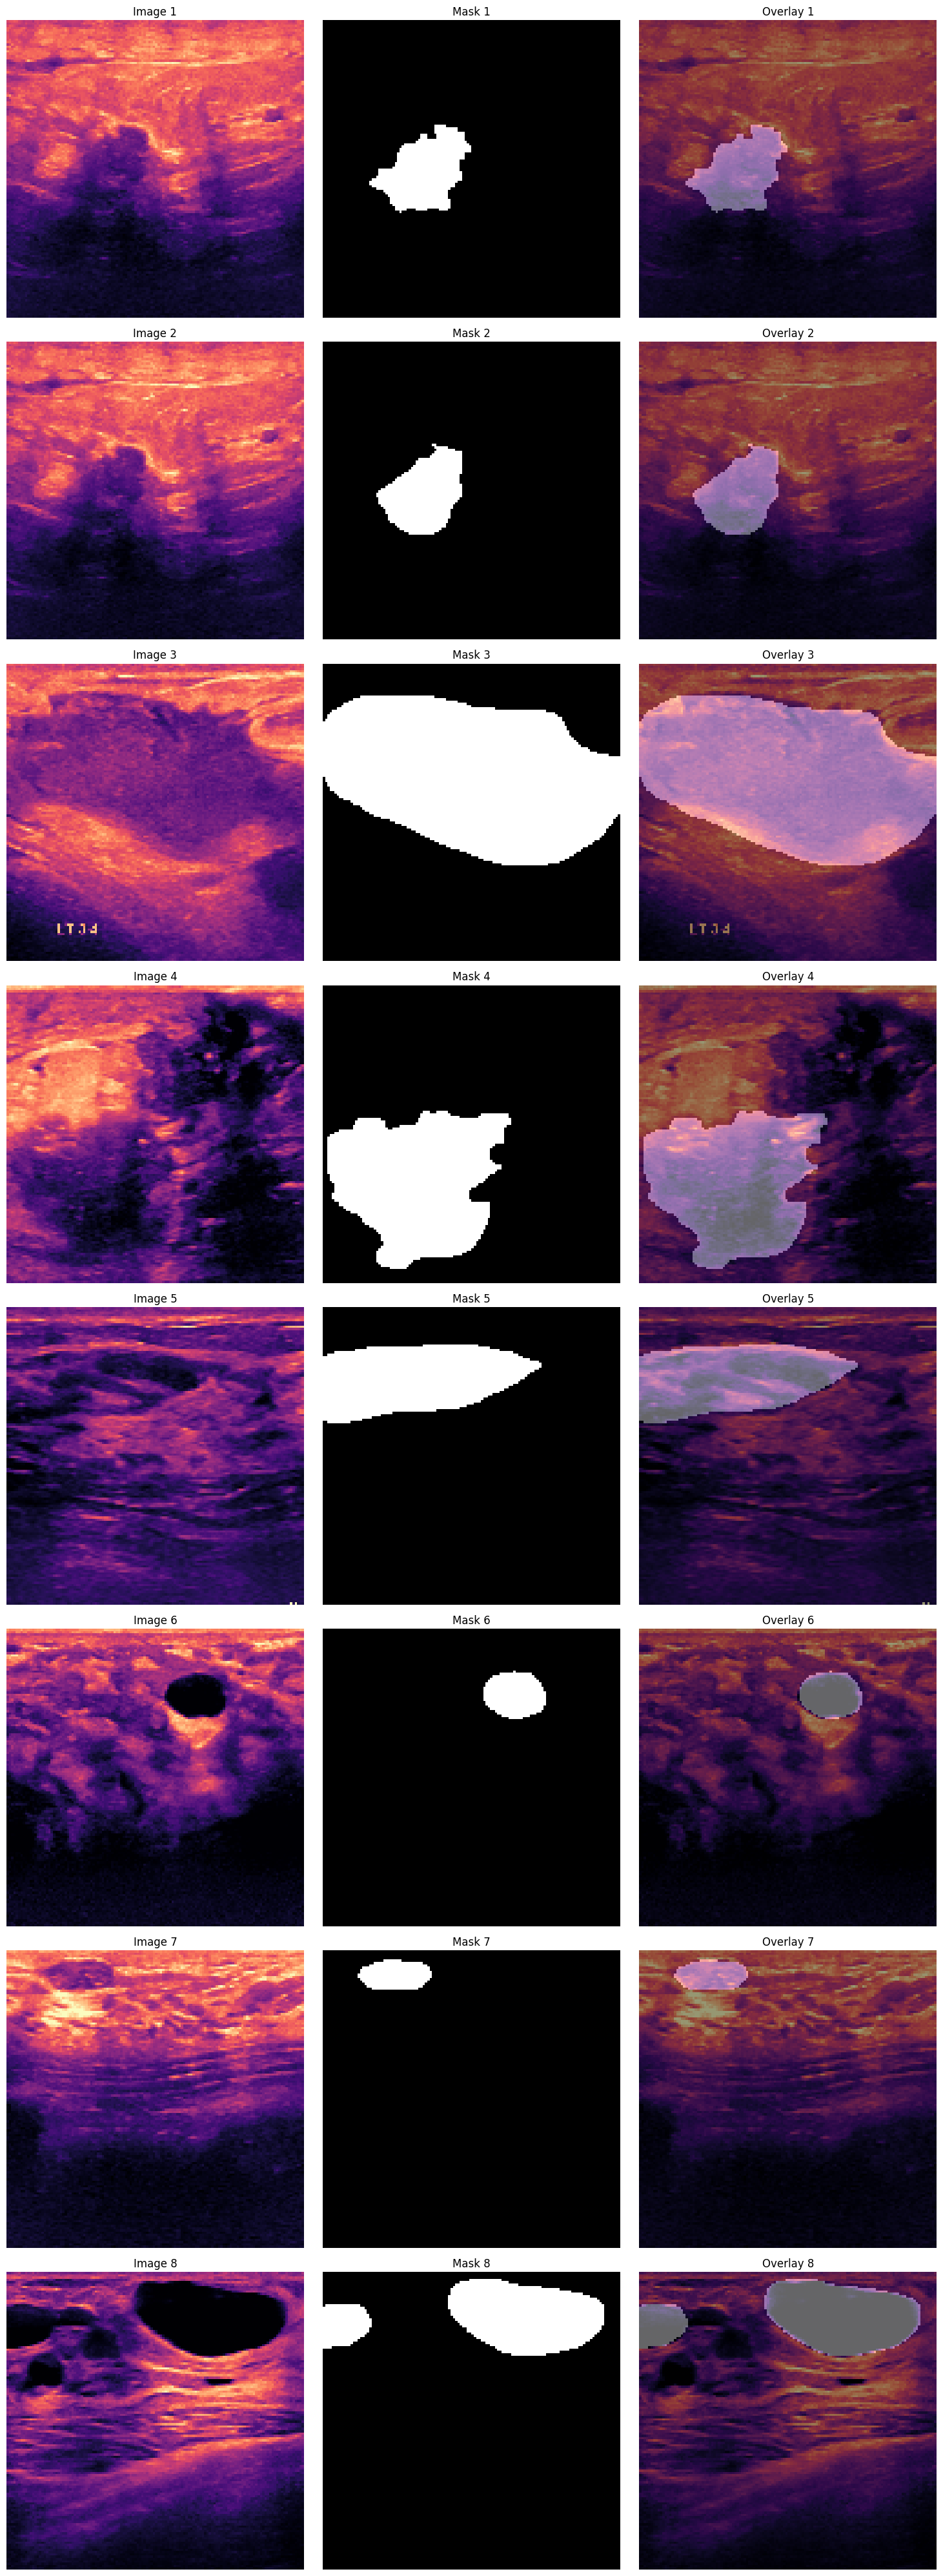

In [ ]:
num_rows=8
plot_dataset_samples(data_train, num_rows, reverse_pixel=reverse_pixel)


Fold 1

--- Training Fold 1 ---
Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7218 - dice: 0.5760 - iou: 0.4563 - loss: 0.6925
Epoch 1: val_loss improved from None to 0.51412, saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_1.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_1.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 334s 10s/step - accuracy: 0.8098 - dice: 0.6534 - iou: 0.5370 - loss: 0.6433 - val_accuracy: 0.8408 - val_dice: 0.6064 - val_iou: 0.5017 - val_loss: 0.5141 - learning_rate: 0.0010
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8776 - dice: 0.7314 - iou: 0.6185 - loss: 0.5861
Epoch 2: val_loss improved from 0.51412 to 0.44626, saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_1.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_1.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.8790 - dice: 0.7356 - iou: 0.6232 - loss: 0.5808 - val_accuracy: 0.8865 - val_dice: 0.5280 - val_iou: 0.4647 - val_loss: 0.4463 - learning_rate: 0.0010
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8909 - dice: 0.7491 - iou: 0.6398 - loss: 0.5623
Epoch 3: val_loss did not improve from 0.44626
33/33 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.8949 - dice: 0.7638 - iou: 0.6549 - loss: 0.5525 - val_accuracy: 0.8663 - val_dice: 0.5101 - val_iou: 0.4472 - val_loss: 0.5030 - learning_rate: 0.0010
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9008 - dice: 0.7897 - iou: 0.6816 - loss: 0.5253
Epoch 4: val_loss did not improve from 0.44626
33/33 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.9016 - dice: 0.7800 - iou: 0.6726 - loss: 0.5266 - val_accuracy: 0.8849 - val_dice: 0.5086 - val_iou: 0

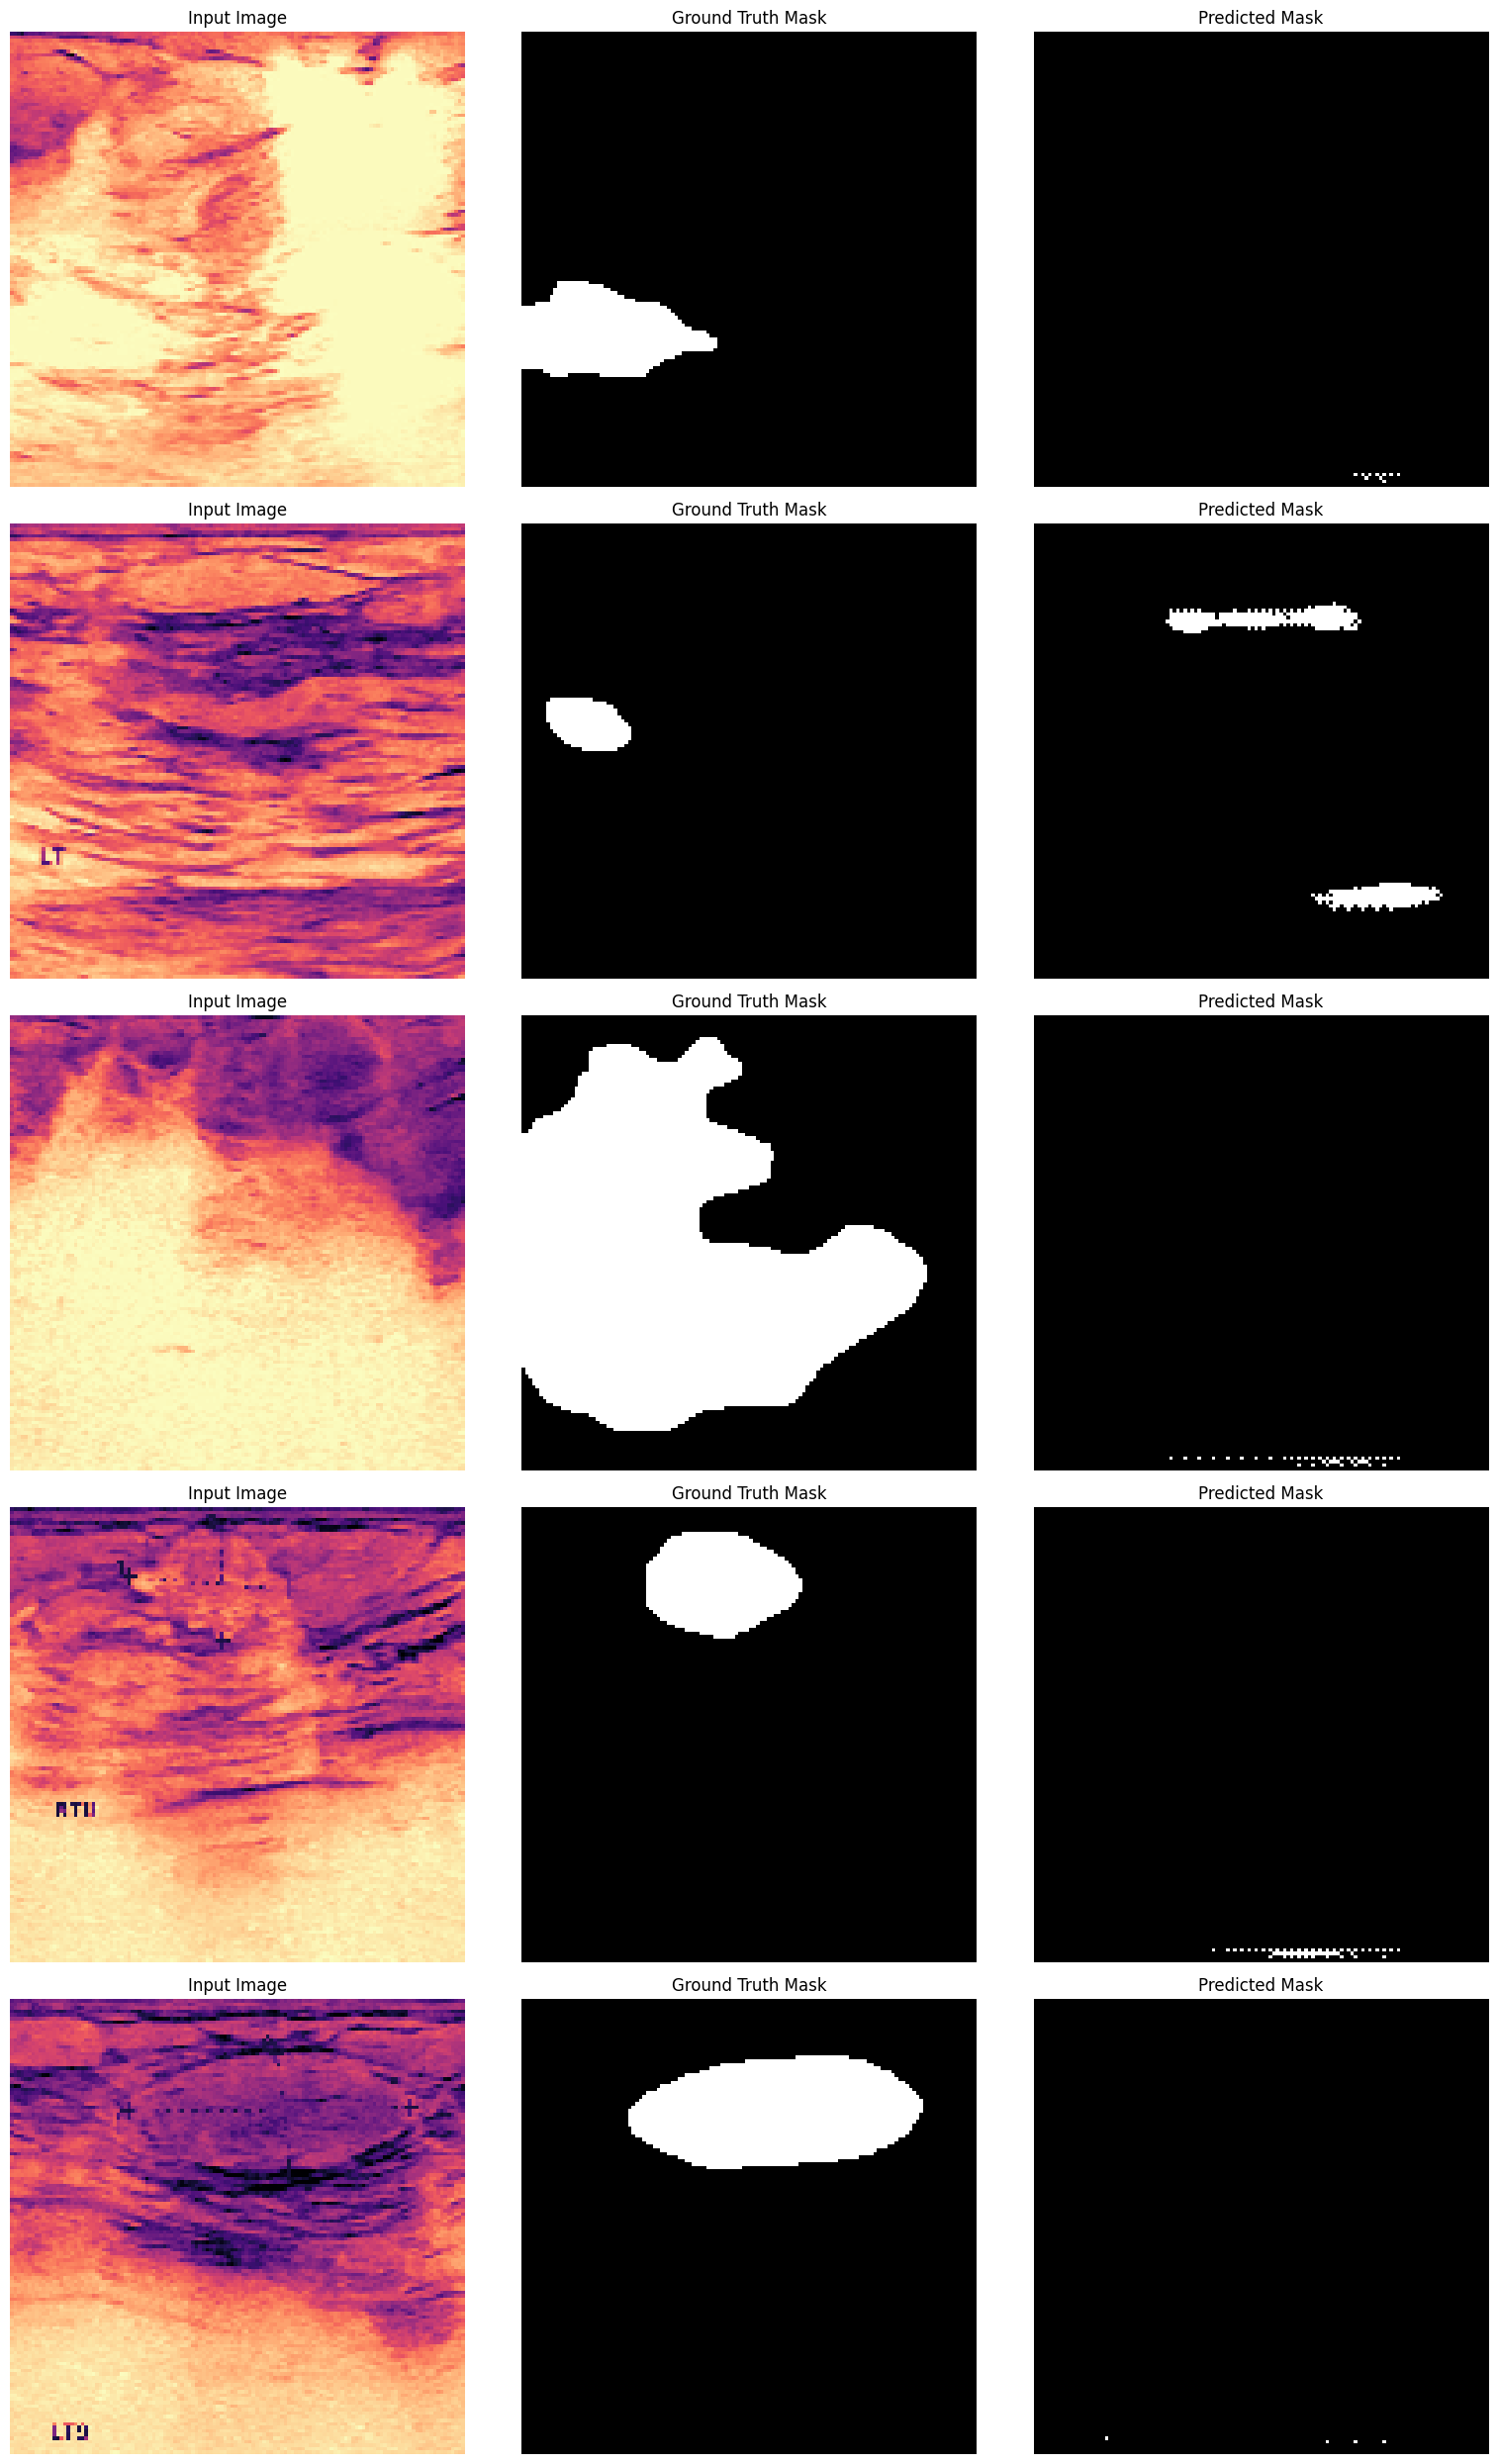

--- Completed Fold 1 ---

Fold 2

--- Training Fold 2 ---
Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5648 - dice: 0.4777 - iou: 0.3483 - loss: 0.7165
Epoch 1: val_loss improved from None to 320.65240, saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_2.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7110 - dice: 0.5827 - iou: 0.4596 - loss: 0.6643 - val_accuracy: 0.1082 - val_dice: 0.1034 - val_iou: 0.0582 - val_loss: 320.6524 - learning_rate: 0.0010
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8699 - dice: 0.7196 - iou: 0.6067 - loss: 0.5872
Epoch 2: val_loss improved from 320.65240 to 40.93561, saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/Bus/ResultData01Colab/best_model_fold_2.h5
33/33 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.8724 - dice: 0.7274 - iou: 0.6141 - loss: 0.5820 - val_accuracy: 0.1162 - val_dice: 0.1129 - val_iou: 0.0631 - val_loss: 40.9356 - learning_rate: 0.0010
Epoch 3/5
16/33 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.8816 - dice: 0.7531 - iou: 0.6391 - loss: 0.5566

In [ ]:
for fold, (train_idx, test_idx) in enumerate(kfold.split(image_paths)):
    print(f"\nFold {fold + 1}")

    # Get train/val splits
    train_images = [image_paths[i] for i in train_idx]
    train_masks = [mask_paths[i] for i in train_idx]
    test_images = [image_paths[i] for i in test_idx]
    test_masks = [mask_paths[i] for i in test_idx]

    data_train = ImageMaskGenerator(
        image_paths = train_images,
        mask_paths = train_masks,
        batch_size = batch_size,
        size = size,
        data_mode = 'train',
        return_one_hot = return_one_hot,
        num_classes = num_classes,
        augmentation = augmentation,
        apply_bilateral_filter = apply_bilateral_filter,
        test_size = test_size,
        val_size = val_size,
        flip_prob = flip_prob,
        flip_left_right_prob = flip_left_right_prob,
        rotation_prob = rotation_prob,
        shift_percentage = shift_percentage,
        shift_prob = shift_prob,
        shift_with_zero_padding = shift_with_zero_padding,
        reverse_pixel = reverse_pixel,
        save_path = result_path,
        use_previous_attempt = use_previous_attempt,
        using_kfold = True
    )

    data_test = ImageMaskGenerator(
        image_paths = test_images,
        mask_paths = test_masks,
        batch_size = batch_size,
        size = size,
        data_mode = 'test',
        return_one_hot = return_one_hot,
        num_classes = num_classes,
        augmentation = False,
        apply_bilateral_filter = apply_bilateral_filter,
        reverse_pixel = reverse_pixel,
        save_path = result_path,
        use_previous_attempt = use_previous_attempt,
        using_kfold = True
    )


    # Write the rest of the code ... 👇
    # 1. Build the U-Net Model
    model = simple_unet(input_shape=(size, size, 1),
                        num_classes=num_classes,
                        filters=16,
                        depth=3)

    # 2. Compile the Model
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy', metrics_instance.dice, metrics_instance.iou])

    # 3. Define Callbacks
    checkpoint_path = os.path.join(result_path, f'best_model_fold_{fold+1}.h5')
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss',
                                           save_best_only=True, mode='min', verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=3, min_lr=1e-6, verbose=1)
    ]

    # 4. Train the Model
    print(f"\n--- Training Fold {fold + 1} ---")
    history = model.fit(
        data_train,
        validation_data=data_test,
        epochs=num_epochs,
        callbacks=callbacks,
        verbose=1
    )

    # 5. Save Training History
    import json
    history_dir = os.path.join(result_path, 'histories')
    os.makedirs(history_dir, exist_ok=True)
    with open(os.path.join(history_dir, f'history_fold_{fold+1}.json'), 'w') as f:
        json.dump(history.history, f)

    # 6. Load best model & visualize predictions
    best_model = tf.keras.models.load_model(
        checkpoint_path,
        custom_objects={
            'class_balanced_loss': class_balanced_loss,
            'dice': metrics_instance.dice,
            'iou': metrics_instance.iou
        }
    )
    try:
        visualize_test_samples(data_test, best_model, num_samples=5,
                               class_color_label=class_color_label,
                               save_path=result_path, index=fold)
    except Exception as e:
        print(f"Visualization error: {e}")

    # 7. Clear GPU/RAM for the next fold
    tf.keras.backend.clear_session()
    print(f"--- Completed Fold {fold + 1} ---")